In [13]:
import matplotlib.pyplot as plt
from pathlib import Path
import json
from collections import Counter
import pandas as pd

In [ ]:
path = Path("../data/results")

files = list(path.glob("*-grype.json"))

len(files), files[:3]

(3,
 [PosixPath('../data/results/Flowise-grype.json'),
  PosixPath('../data/results/FlowiseChatEmbed-grype.json'),
  PosixPath('../data/results/FlowiseEmbedReact-grype.json')])

In [ ]:
for file in files:
    print(f"\n📁 {file.name}")

    with open(file) as f:
        data = json.load(f)

    print("Keys:", data.keys())


📁 Flowise-grype.json
Keys: dict_keys(['total_vulnerabilities', 'vulnerabilities_by_severity', 'vulnerabilities', 'grype_metadata'])

📁 FlowiseChatEmbed-grype.json
Keys: dict_keys(['total_vulnerabilities', 'vulnerabilities_by_severity', 'vulnerabilities', 'grype_metadata'])

📁 FlowiseEmbedReact-grype.json
Keys: dict_keys(['total_vulnerabilities', 'vulnerabilities_by_severity', 'vulnerabilities', 'grype_metadata'])


In [ ]:
for file in files:
    print(f"\n📁 {file.name}")

    with open(file) as f:
        data = json.load(f)

    matches = data.get("matches", [])

    print("Total matches:", len(matches))

    if matches:
        print("Keys match[0]:", matches[0].keys())
        print("Keys vulnerability:", matches[0]["vulnerability"].keys())
        print("Keys artifact:", matches[0]["artifact"].keys())


📁 Flowise-grype.json
Total matches: 0

📁 FlowiseChatEmbed-grype.json
Total matches: 0

📁 FlowiseEmbedReact-grype.json
Total matches: 0


In [ ]:
vuln_keys = Counter()

for file in files:
    data = json.load(open(file))

    for v in data.get("vulnerabilities", []):
        vuln_keys.update(v.keys())

vuln_keys

Counter({'package_name': 419,
         'current_version': 419,
         'vuln_id': 419,
         'vuln_severity': 419,
         'fix_version': 419,
         'message': 419,
         'cwe': 419,
         'cvss_score': 419,
         'type': 419})

In [35]:
path = Path("../data/results")

records = []

for file in path.glob("*-grype.json"):
    with open(file) as f:
        data = json.load(f)

    repo = file.stem

    for v in data.get("vulnerabilities", []):
        records.append({
            "repo": repo,
            "package": v.get("package_name"),
            "version": v.get("current_version"),
            "cve": v.get("vuln_id"),
            "severity": v.get("vuln_severity"),
            "cvss": v.get("cvss_score"),
            "fix_version": v.get("fix_version"),
            "cwe": v.get("cwe"),
            "type": v.get("type"),
            "message": v.get("message")
        })

df_grype = pd.DataFrame(records)

df_grype.head()

,repo,package,version,cve,severity,cvss,fix_version,cwe,type,message
0,Flowise-grype,vite,4.5.2,GHSA-4r4m-qw57-chr8,low,0,N/A,N/A,vulnerability,Vite has a `server.fs.deny` bypassed for `inli...
1,Flowise-grype,vite,5.1.6,GHSA-4r4m-qw57-chr8,low,0,N/A,N/A,vulnerability,Vite has a `server.fs.deny` bypassed for `inli...
2,Flowise-grype,vite,4.5.2,GHSA-x574-m823-4x7w,low,0,N/A,N/A,vulnerability,Vite bypasses server.fs.deny when using ?raw??
3,Flowise-grype,vite,5.1.6,GHSA-x574-m823-4x7w,low,0,N/A,N/A,vulnerability,Vite bypasses server.fs.deny when using ?raw??
4,Flowise-grype,tough-cookie,2.5.0,GHSA-72xf-g2v4-qvf3,low,0,N/A,N/A,vulnerability,tough-cookie Prototype Pollution vulnerability


In [36]:
df_grype.shape[0]

419

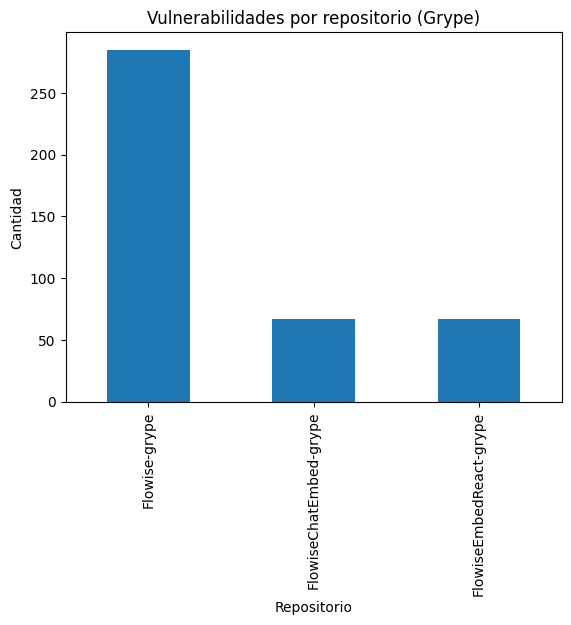

In [37]:
df_grype["repo"].value_counts().plot(kind="bar")
plt.title("Vulnerabilidades por repositorio (Grype)")
plt.xlabel("Repositorio")
plt.ylabel("Cantidad")
plt.show()

In [38]:
pd.crosstab(df_grype["repo"], df_grype["severity"])

severity,low
repo,
Flowise-grype,285
FlowiseChatEmbed-grype,67
FlowiseEmbedReact-grype,67


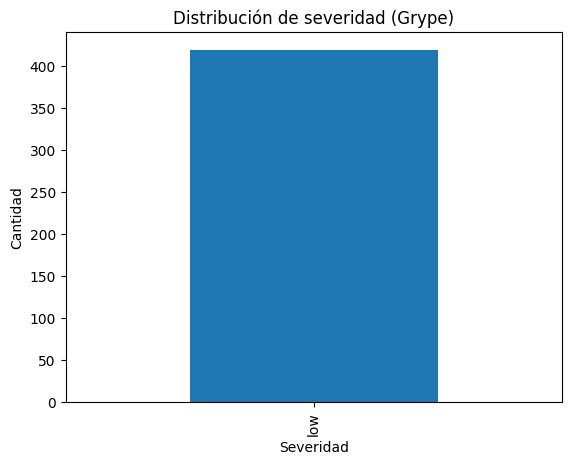

In [39]:
df_grype["severity"].value_counts().plot(kind="bar")
plt.title("Distribución de severidad (Grype)")
plt.xlabel("Severidad")
plt.ylabel("Cantidad")
plt.show()

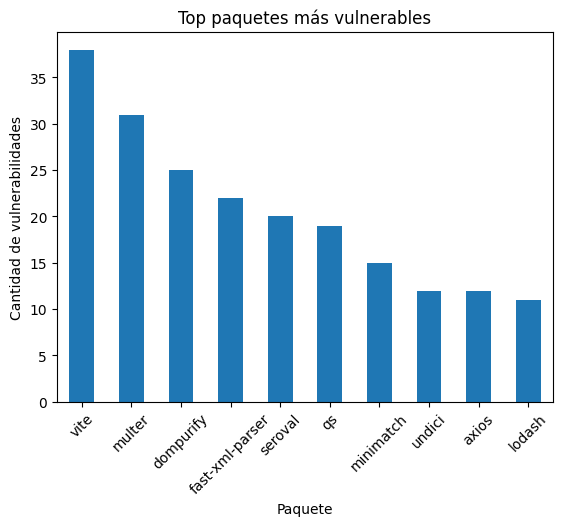

In [40]:
df_grype["package"].value_counts().head(10).plot(kind="bar")
plt.title("Top paquetes más vulnerables")
plt.xlabel("Paquete")
plt.ylabel("Cantidad de vulnerabilidades")
plt.xticks(rotation=45)
plt.show()

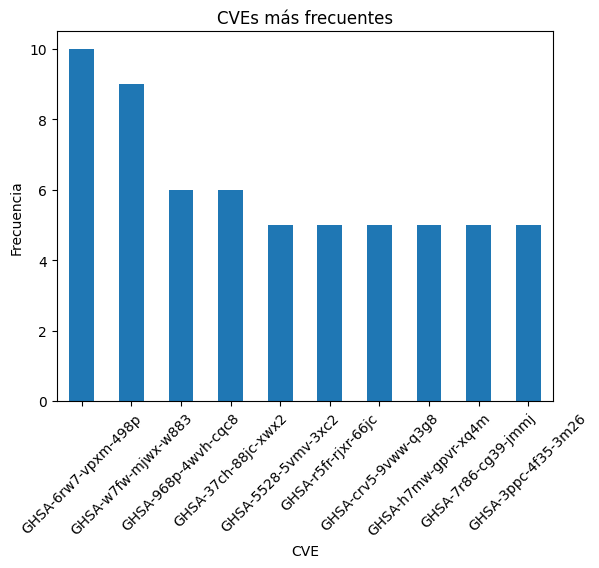

In [41]:
df_grype["cve"].value_counts().head(10).plot(kind="bar")
plt.title("CVEs más frecuentes")
plt.xlabel("CVE")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

In [48]:
cve_summary = (
    df_grype
    .groupby("cve")
    .agg(
        total_occurrences=("cve", "count"),
        repos=("repo", lambda x: sorted(set(x))),
        messages=("message", lambda x: list(set(x))),
        n_repos=("repo", "nunique"),
        packages=("package", lambda x: sorted(set(x))),
        severities=("severity", lambda x: sorted(set(x))),
        avg_cvss=("cvss", "mean")
    )
    .sort_values("total_occurrences", ascending=False)
    .reset_index()
)

cve_summary.head(10)

,cve,total_occurrences,repos,messages,n_repos,packages,severities,avg_cvss
0,GHSA-6rw7-vpxm-498p,10,"[Flowise-grype, FlowiseChatEmbed-grype, Flowis...",[qs's arrayLimit bypass in its bracket notatio...,3,[qs],[low],0.0
1,GHSA-w7fw-mjwx-w883,9,"[Flowise-grype, FlowiseChatEmbed-grype, Flowis...",[qs's arrayLimit bypass in comma parsing allow...,3,[qs],[low],0.0
2,GHSA-968p-4wvh-cqc8,6,"[Flowise-grype, FlowiseChatEmbed-grype, Flowis...",[Babel has inefficient RegExp complexity in ge...,3,"[@babel/helpers, @babel/runtime]",[low],0.0
3,GHSA-37ch-88jc-xwx2,6,"[Flowise-grype, FlowiseChatEmbed-grype, Flowis...",[path-to-regexp vulnerable to Regular Expressi...,3,[path-to-regexp],[low],0.0
4,GHSA-5528-5vmv-3xc2,5,"[Flowise-grype, FlowiseChatEmbed-grype, Flowis...",[Multer Vulnerable to Denial of Service via Un...,3,[multer],[low],0.0
5,GHSA-39q2-94rc-95cp,5,"[Flowise-grype, FlowiseChatEmbed-grype, Flowis...",[DOMPurify's ADD_TAGS function form bypasses F...,3,[dompurify],[low],0.0
6,GHSA-3ppc-4f35-3m26,5,[Flowise-grype],[minimatch has a ReDoS via repeated wildcards ...,1,[minimatch],[low],0.0
7,GHSA-23c5-xmqv-rm74,5,[Flowise-grype],[minimatch ReDoS: nested *() extglobs generate...,1,[minimatch],[low],0.0
8,GHSA-crv5-9vww-q3g8,5,"[Flowise-grype, FlowiseChatEmbed-grype, Flowis...",[DOMPurify has a SAFE_FOR_TEMPLATES bypass in ...,3,[dompurify],[low],0.0
9,GHSA-r5fr-rjxr-66jc,5,"[Flowise-grype, FlowiseChatEmbed-grype, Flowis...",[lodash vulnerable to Code Injection via `_.te...,3,"[lodash, lodash-es]",[low],0.0


/tmp/ipykernel_28633/743523575.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


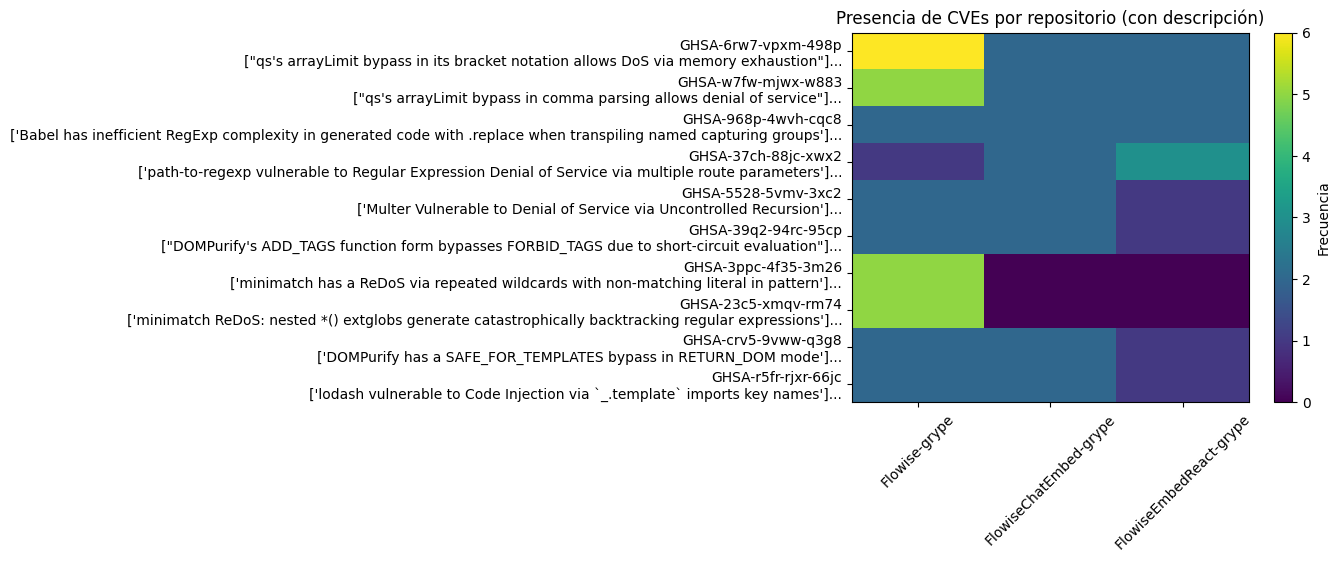

In [49]:
cve_to_msg = dict(zip(cve_summary["cve"], cve_summary["messages"]))

pivot_top_labeled = pivot_top.copy()
pivot_top_labeled.index = [
    f"{cve}\n{cve_to_msg.get(cve, '')[:60]}..."
    for cve in pivot_top.index
]

plt.imshow(pivot_top_labeled, aspect="auto")

plt.xticks(range(len(pivot_top.columns)), pivot_top.columns, rotation=45)
plt.yticks(range(len(pivot_top_labeled.index)), pivot_top_labeled.index)

plt.title("Presencia de CVEs por repositorio (con descripción)")
plt.colorbar(label="Frecuencia")

plt.tight_layout()
plt.show()